In [8]:
import os
import pdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
sys.path.append(os.getcwd())
from dotenv import load_dotenv

load_dotenv()

True

In [9]:
sns.set_theme(font_scale=2.1, style='whitegrid')
sns.color_palette("colorblind")
font = {'family' : 'serif',
            # 'weight' : 'bold',
            'size'   : 19}
mpl.rcParams['figure.dpi'] = 600
mpl.rc('font', **font)
mpl.rc('xtick', labelsize=19) 
plt.rcParams["font.family"] = "Nimbus Roman"
mpl.rc('ytick', labelsize=19)

In [10]:
# Load the results
perf_olmo = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "olmo2-7B_full_v2_mult_perf.csv"))
perf_mistral = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "mistral7B_full_v2_mult_perf.csv"))
perf_qwen = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "qwen7B-instruct_full_v2_mult_perf.csv"))
perf_olmo13B = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "olmo2-13B_full_v2_mult_perf.csv"))
perf_qwen14B = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "qwen2.5-14B-instruct_full_v2_mult_perf.csv"))

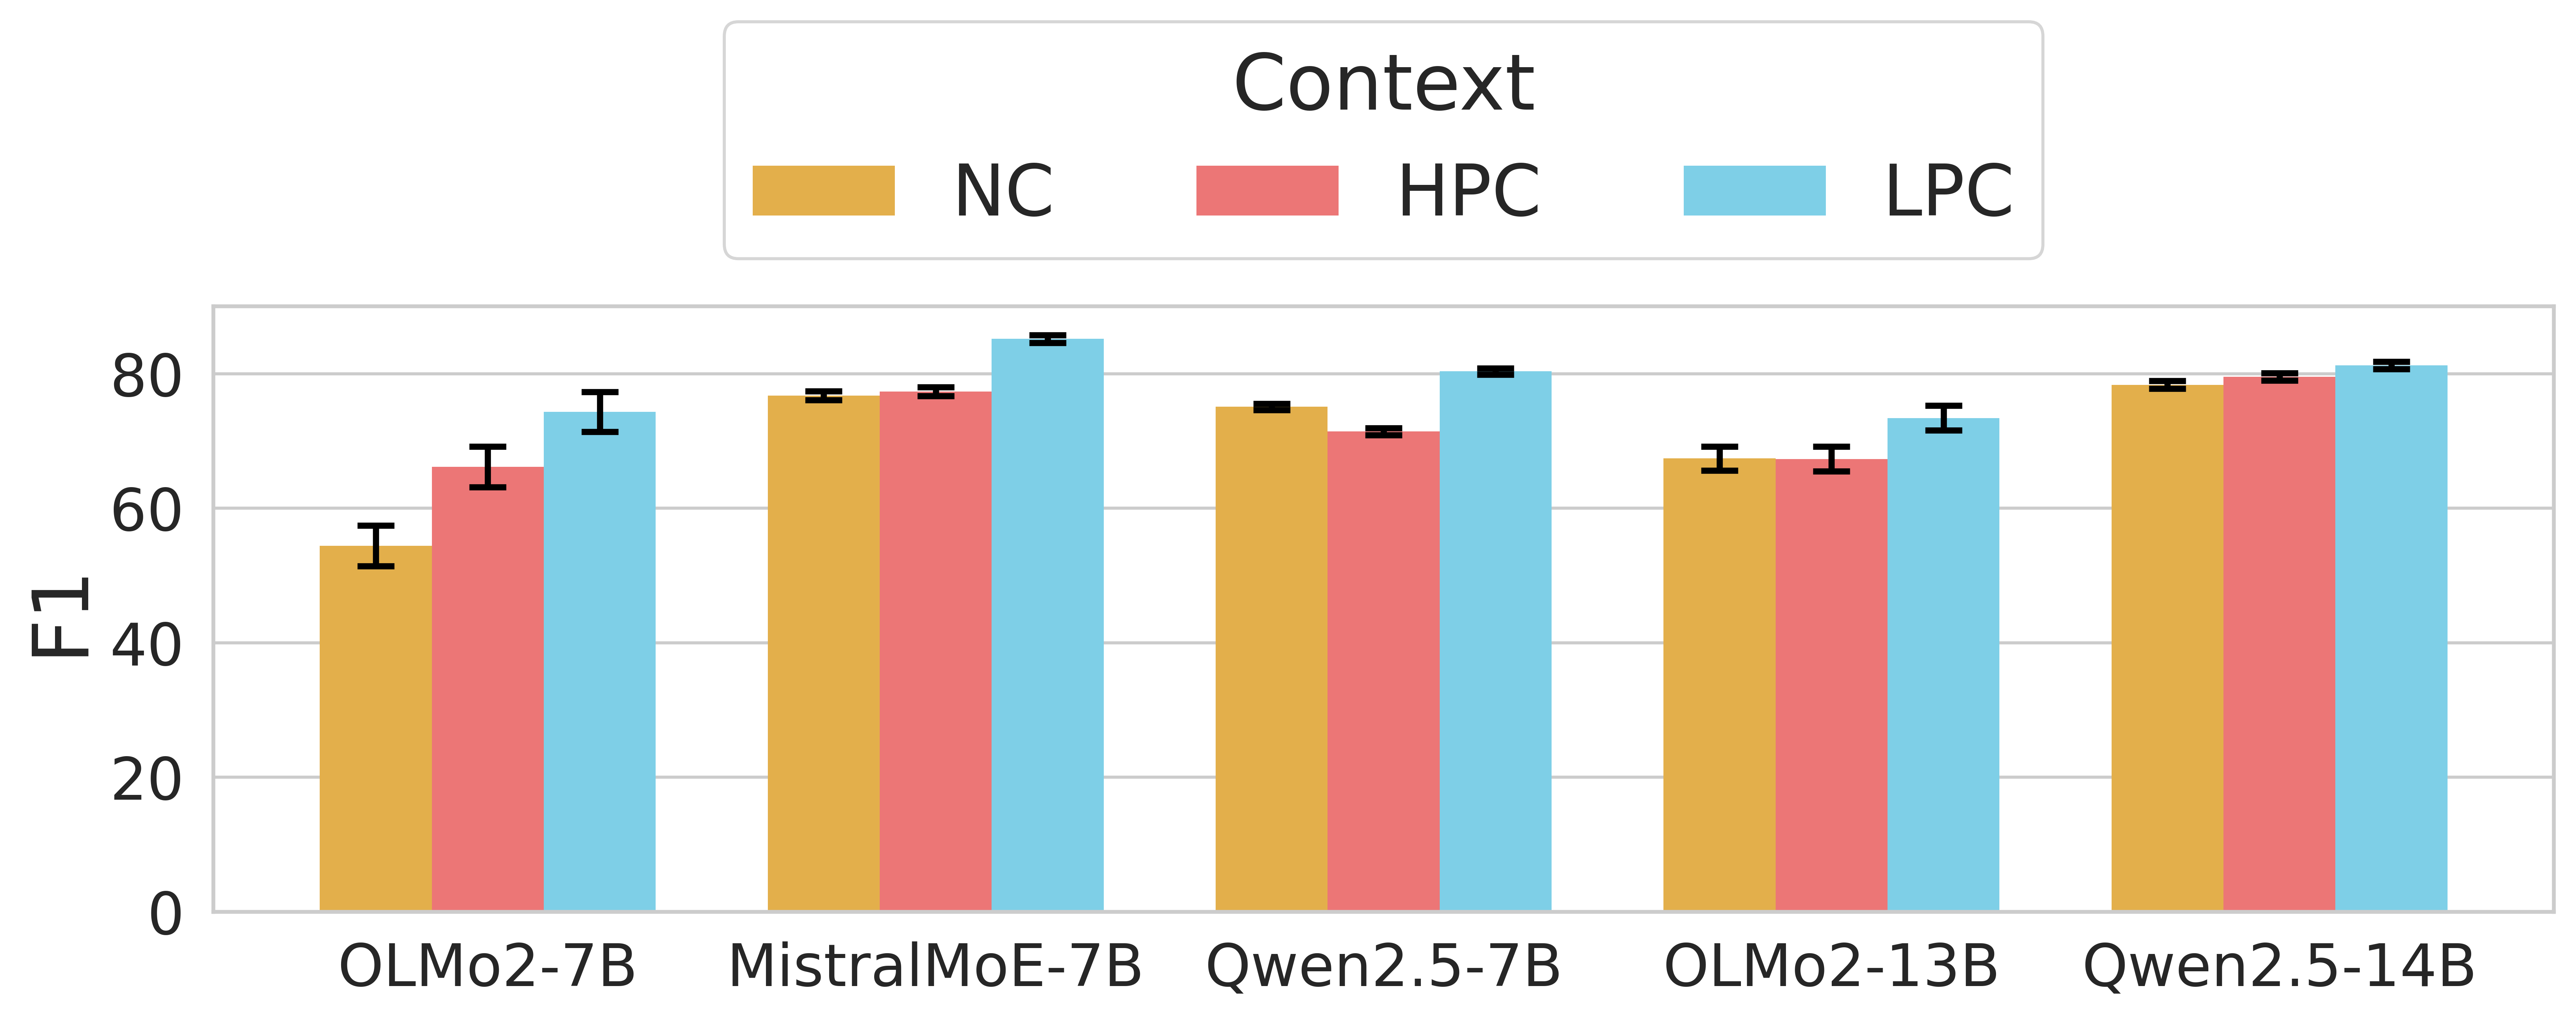

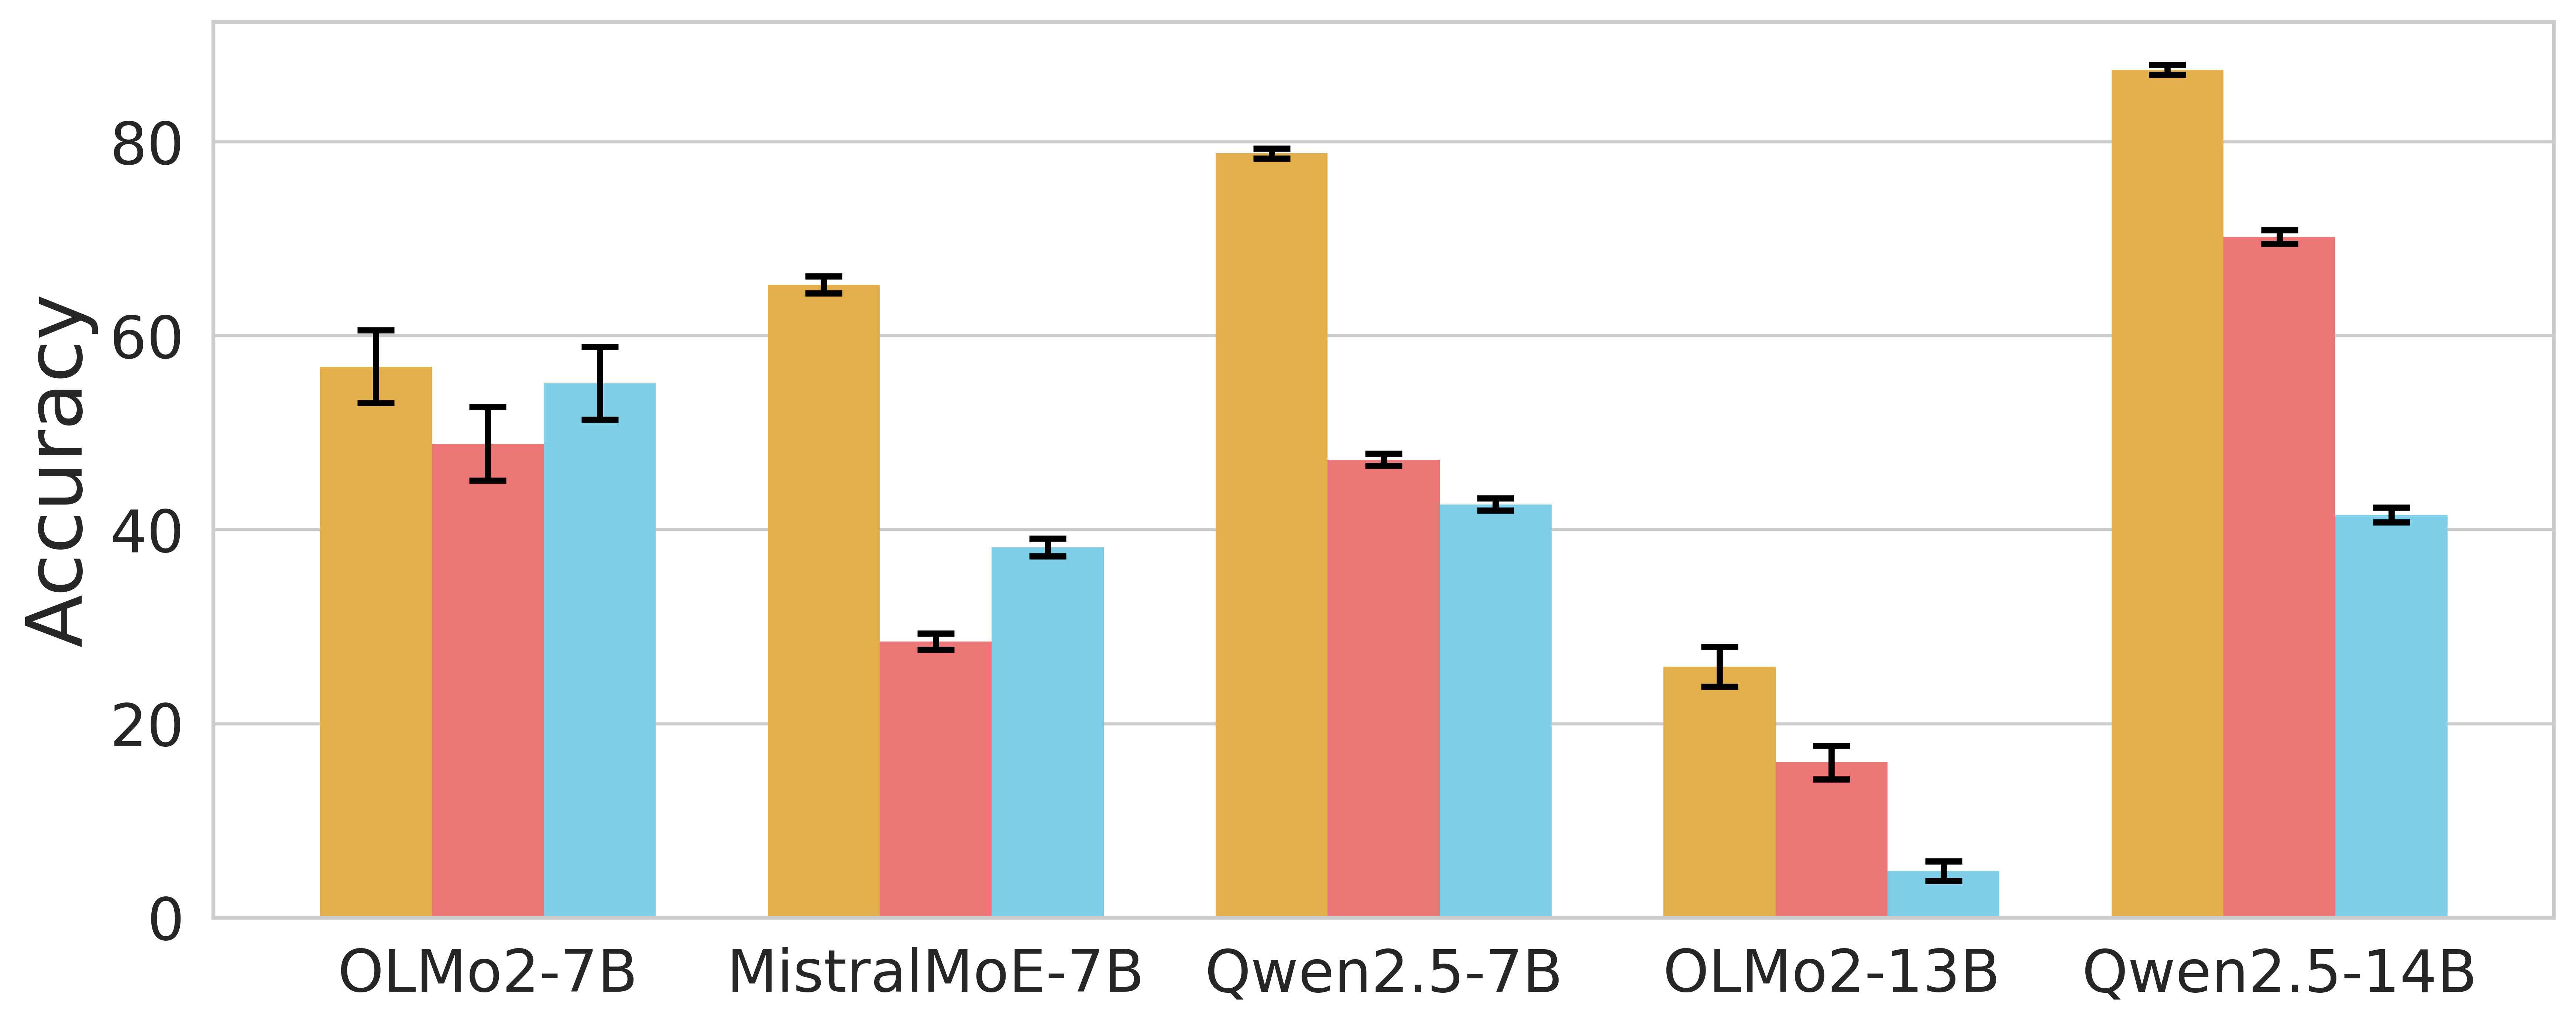

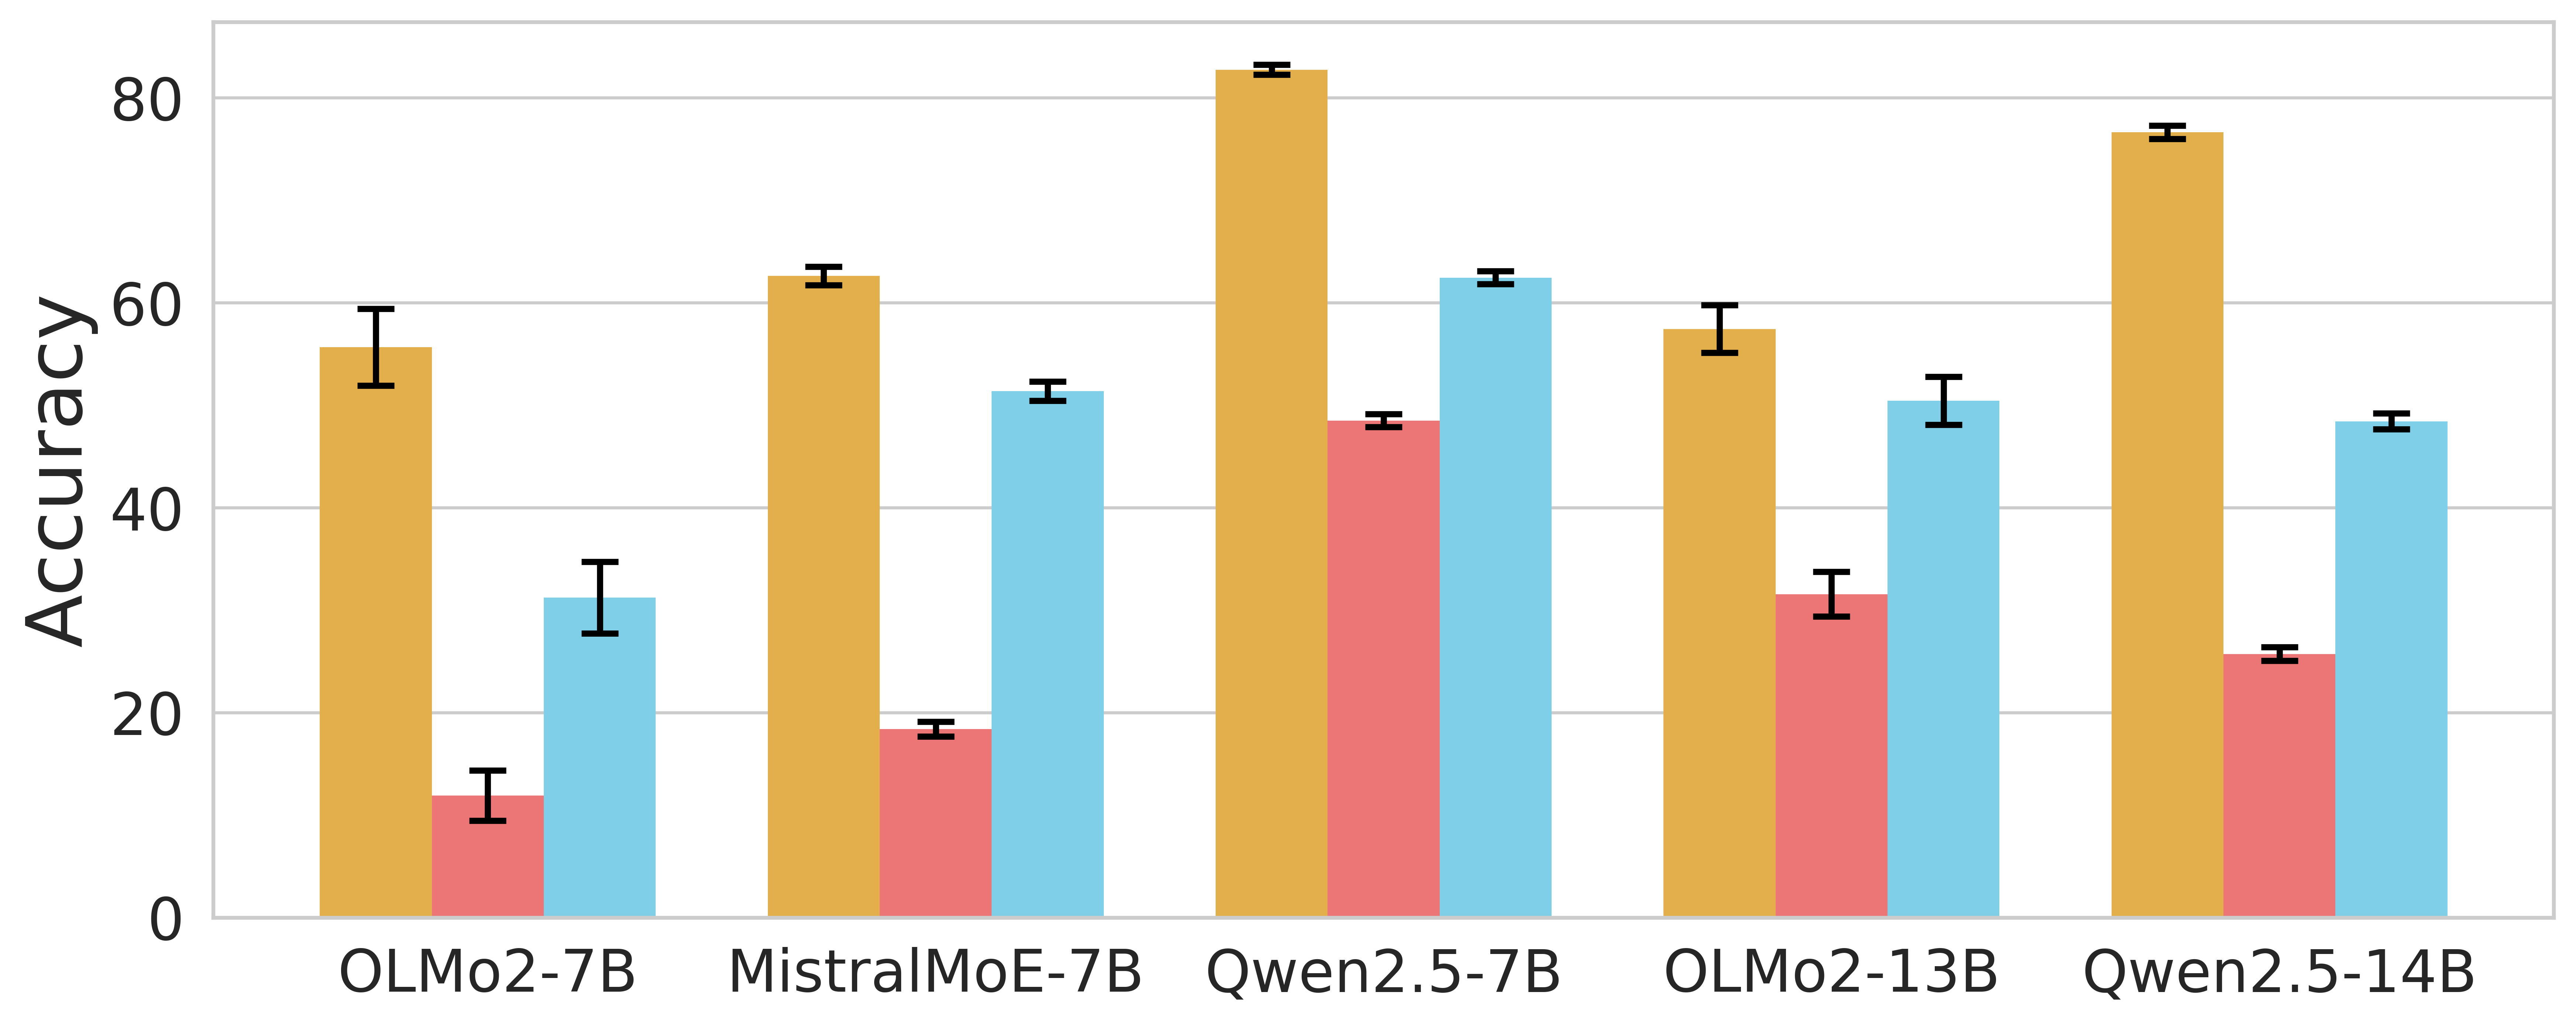

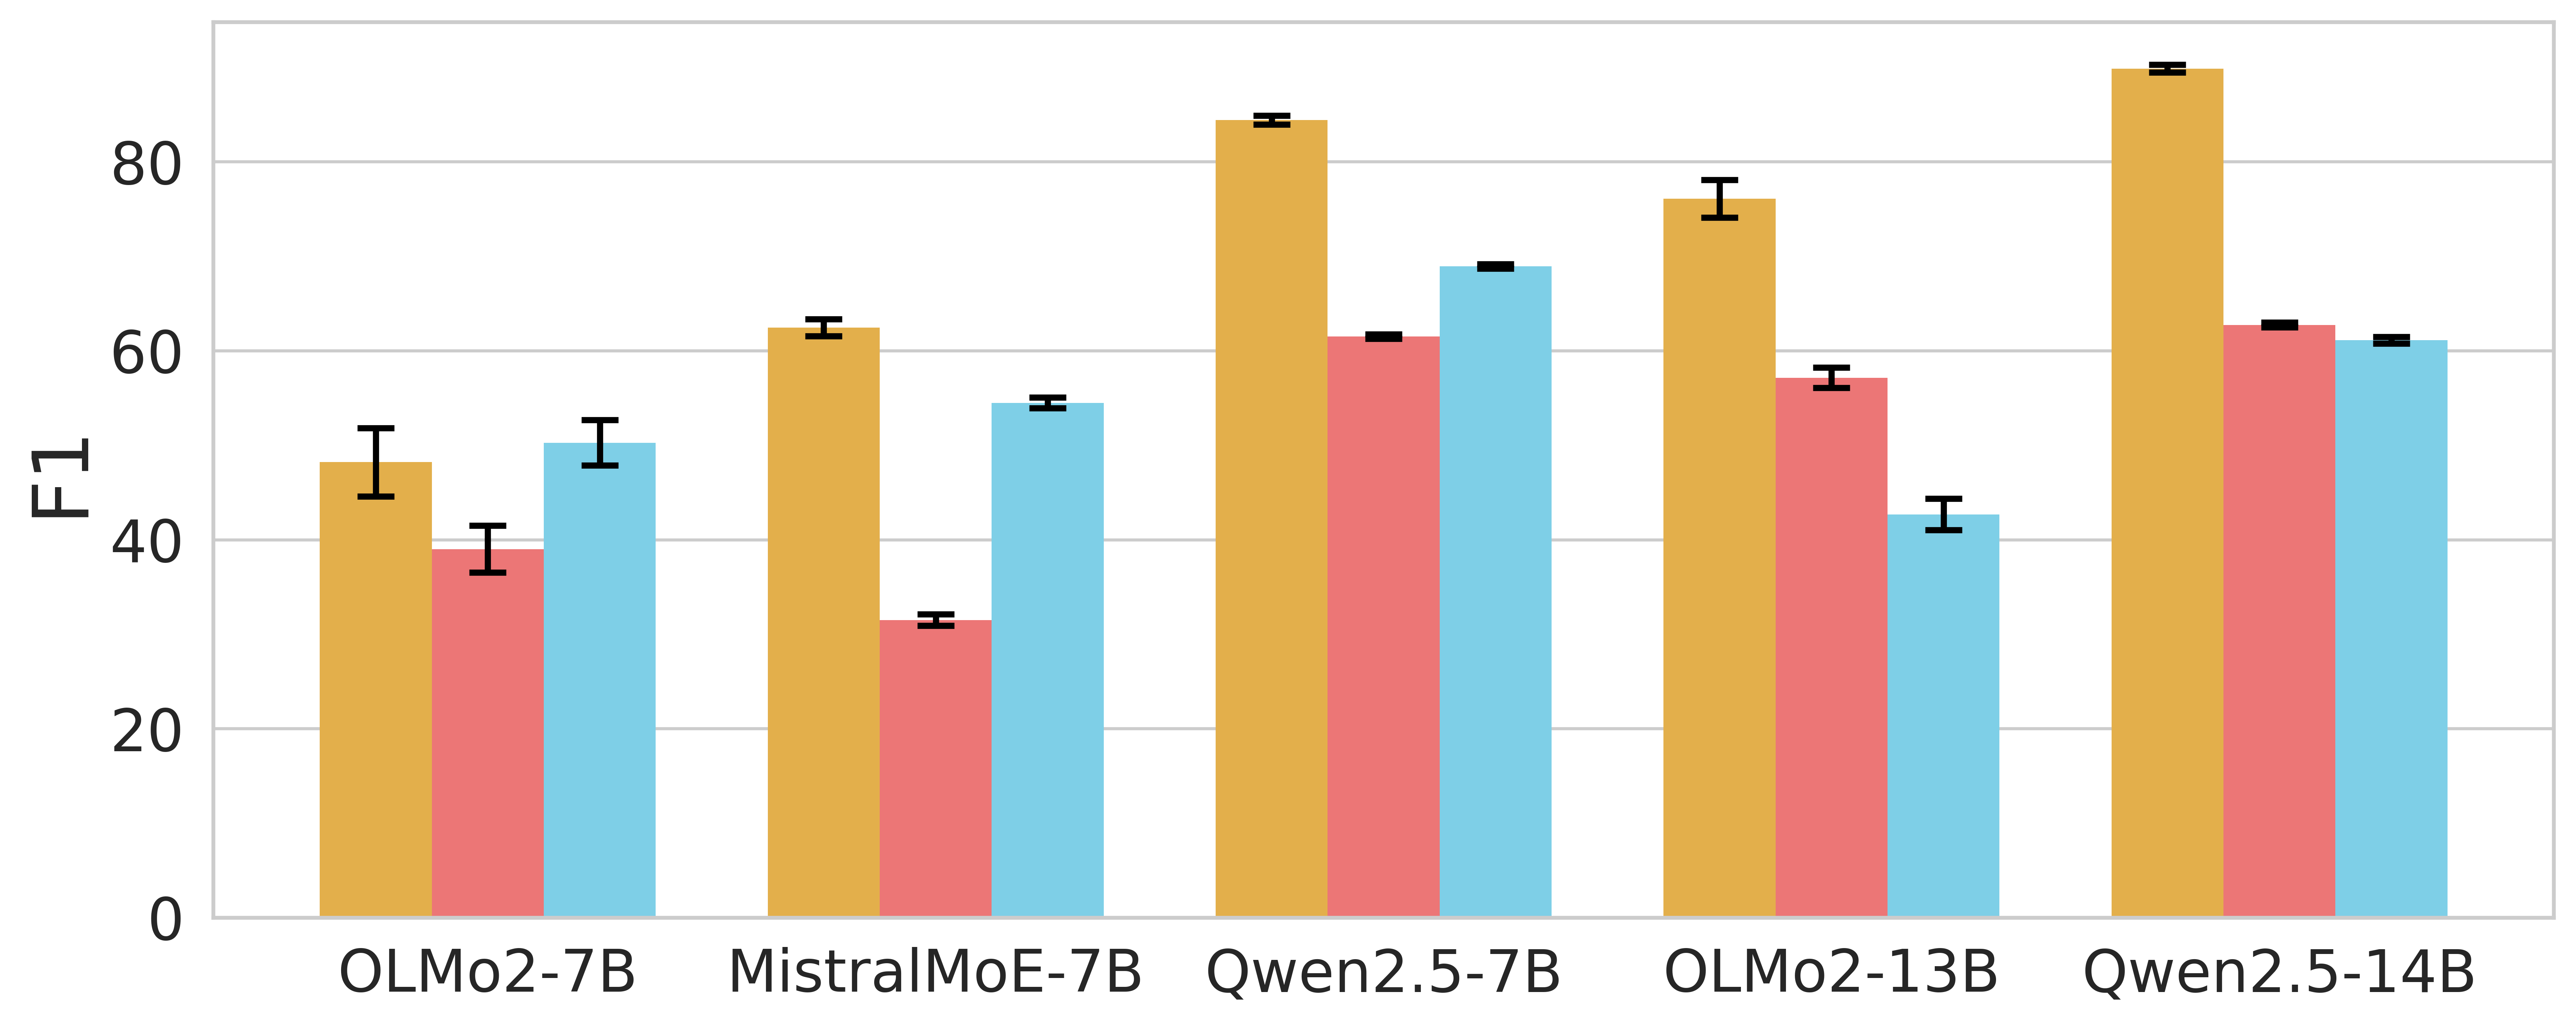

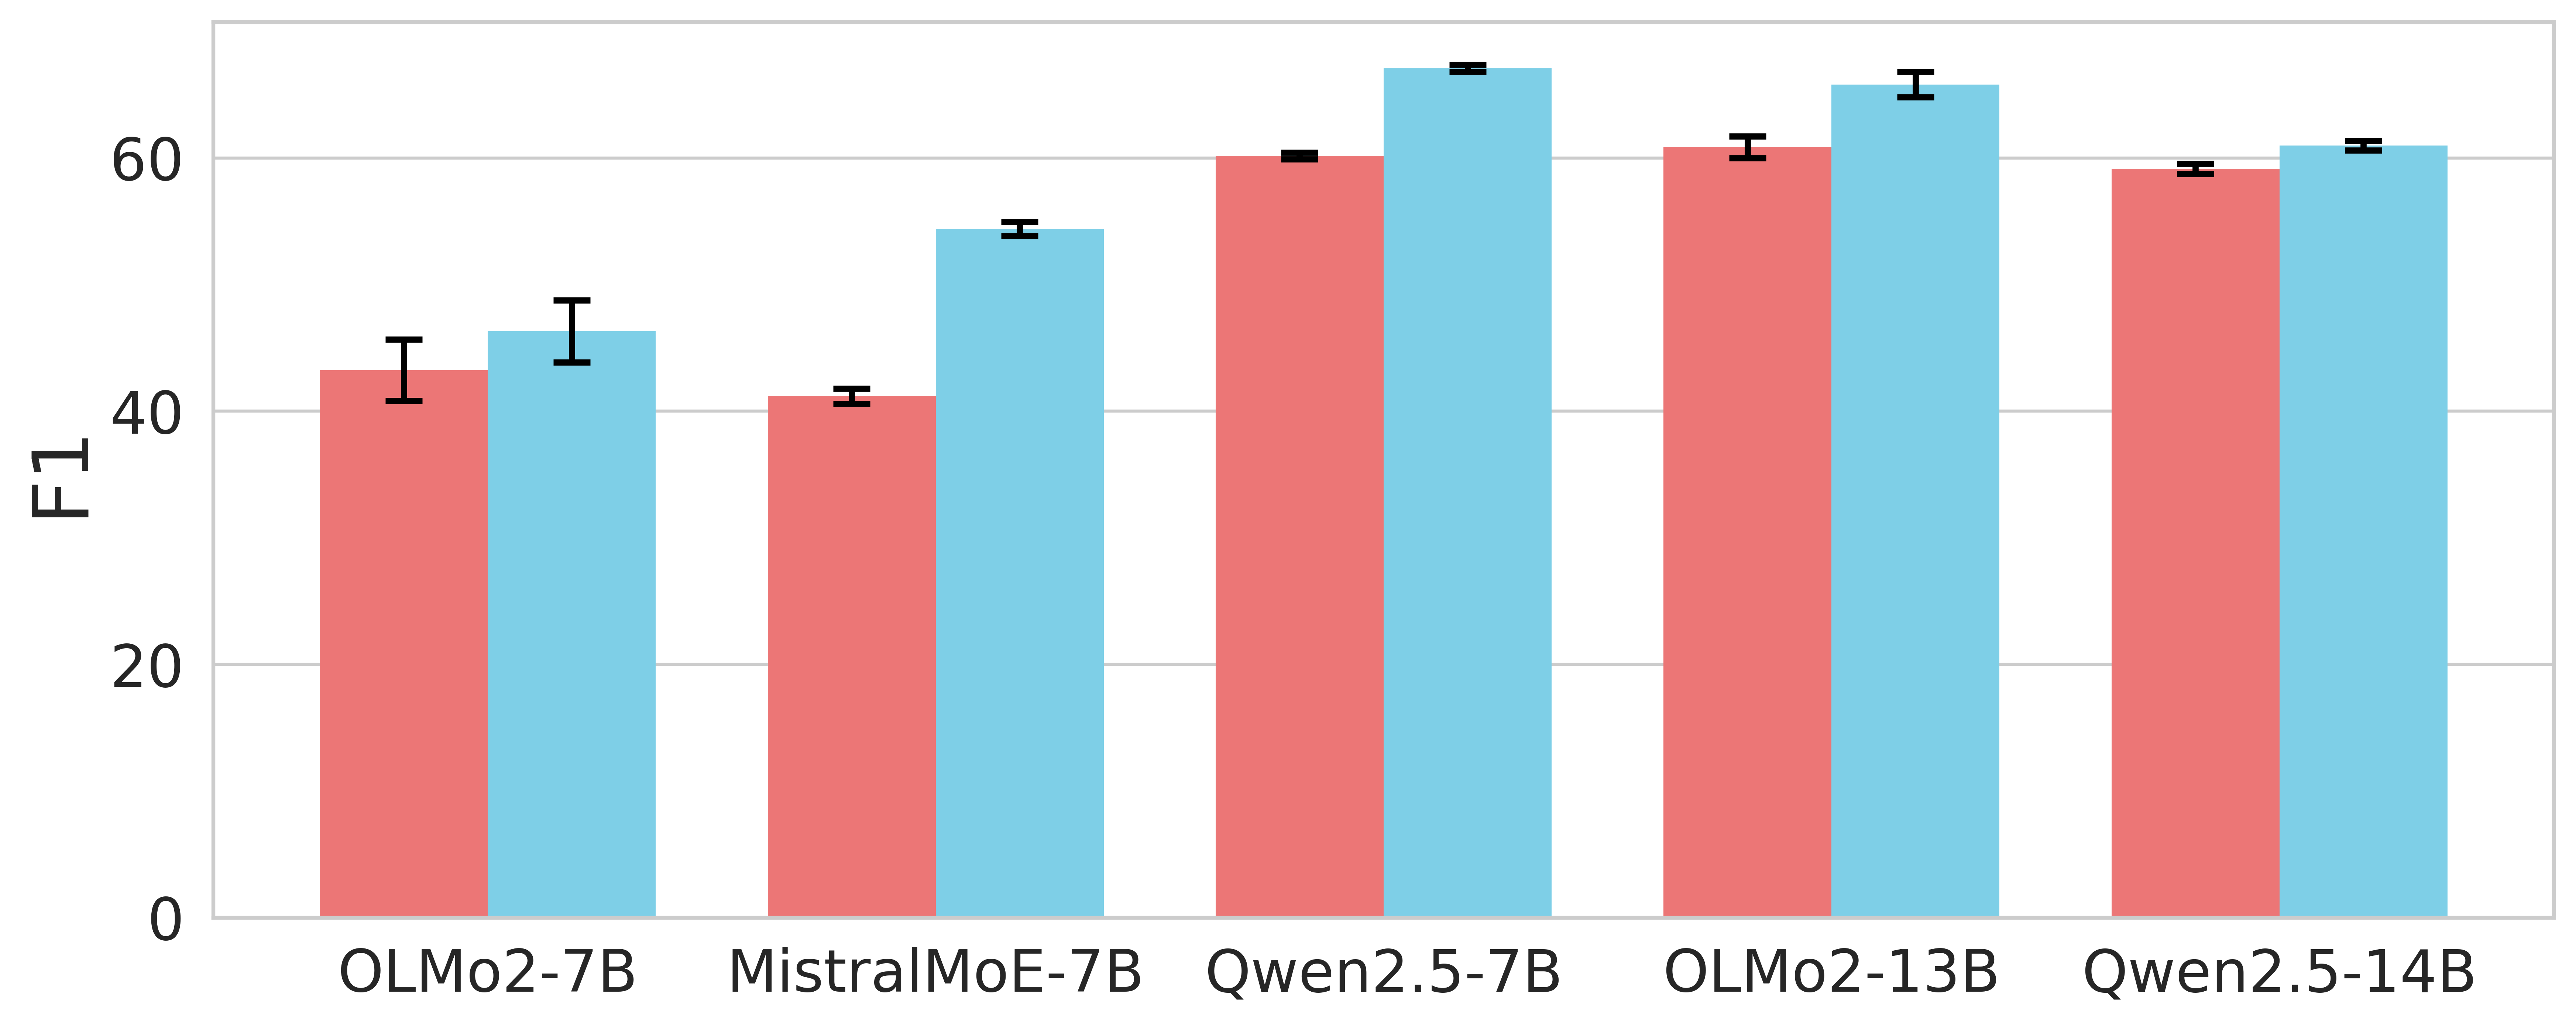

In [5]:
# ------------------------------------------------------------------
# 1)  Combine the three model‑specific DataFrames
# ------------------------------------------------------------------
dfs = []
for name, df in [('OLMo2-7B', perf_olmo), ('MistralMoE-7B', perf_mistral), ('Qwen2.5-7B', perf_qwen), ('OLMo2-13B', perf_olmo13B), ('Qwen2.5-14B', perf_qwen14B)]:
# for name, df in  [('MistralMoE-7B', perf_mistral)]:
    tmp = df.copy()
    tmp['model'] = name                              # tag the model
    dfs.append(tmp)

data = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------------
# 3)  Draw one bar‑plot figure per task
# ------------------------------------------------------------------
sns.set_style('whitegrid')
# Custom color palette
PALETTE   = {'NC': '#fdb731', 'HPC': '#ff6363', 'LPC': '#6cd9f9'}

tasks_list = ['KFextract', 'CK', 'PK', 'PCK', 'RAG']
for idx, t in enumerate(tasks_list):
    # Select metric based on task
    if t in ['CK', 'PK']:
        metric_to_plot = "exact_match"
        ylabel = "Accuracy"
    else:  # KFextract, PCK, RAG
        metric_to_plot = "f1"
        ylabel = "F1"

    # Filter data for the current metric
    task_data = data[data['metric'] == metric_to_plot].copy()

    # ------------------------------------------------------------------
    # 2)  Reshape to long format: one row per (model, task, evidence type)
    # ------------------------------------------------------------------
    long_mean = task_data.melt(
        id_vars=['model', 'task'],
        value_vars=['NC', 'HPC', 'LPC'],                 # evidence types to plot
        var_name='evidence',
        value_name=metric_to_plot
    )

    long_std = task_data.melt(
        id_vars=['model', 'task'],
        value_vars=['NC_std', 'HPC_std', 'LPC_std'],
        var_name='evidence',
        value_name='std'
    )

    long_sem = task_data.melt(
        id_vars=['model', 'task'],
        value_vars=['NC_sem', 'HPC_sem', 'LPC_sem'],
        var_name='evidence',
        value_name='sem'
    )

    long_std['evidence'] = long_std['evidence'].str.replace('_std', '', regex=False)
    long_sem['evidence'] = long_sem['evidence'].str.replace('_sem', '', regex=False)

    long_mean = long_mean.merge(long_sem, on=['model', 'task', 'evidence'])
    long = long_mean.merge(long_std, on=['model', 'task', 'evidence'])

    # choose which evidence types to include
    ev_types = ['HPC', 'LPC'] if t == 'RAG' else ['NC', 'HPC', 'LPC']

    subset = long[(long['task'] == t) & (long['evidence'].isin(ev_types))]
    # palette = sns.color_palette('Set2', n_colors=len(ev_types))

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(
        data=subset,
        x='model',
        y=metric_to_plot,
        hue='evidence',
        palette=PALETTE,
        width=0.75,
        edgecolor='none',
        errorbar=None
    )

    # --- add CI error bars --------------------------------------------------
    for bar, ci in zip(ax.patches, subset['sem']):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.errorbar(x, y, yerr=ci, color='black', capsize=6, elinewidth=2, capthick=2)

    # plt.title(f'Exact-Match Accuracy by Evidence Type  |  Task: {t}')
    plt.xlabel('')
    plt.ylabel(ylabel)

    # Only add legend on the first figure, positioned horizontally outside the frame
    if idx == 0:
        ax.legend(
            title='Context',
            loc='lower center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=3,  # all three contexts in one horizontal row
            frameon=True
        )
    else:
        ax.get_legend().remove()  # remove legend from other figures

    plt.tight_layout()
    plt.savefig(os.path.join(os.environ['base_dir'], "results", "figures", f"{t}_{metric_to_plot}.pdf"), bbox_inches='tight')
    plt.show()

In [6]:
# Save data to csv
# Remove colum that contains "_sem" and "_std"
data_to_save = data.drop(columns=['NC_sem', 'HPC_sem', 'LPC_sem', 'NC_std', 'HPC_std', 'LPC_std', 'HPCE_std', "HPCE_sem"])
data_to_save.to_csv(os.path.join(os.environ['base_dir'], "results", "long_format.csv"), index=False)

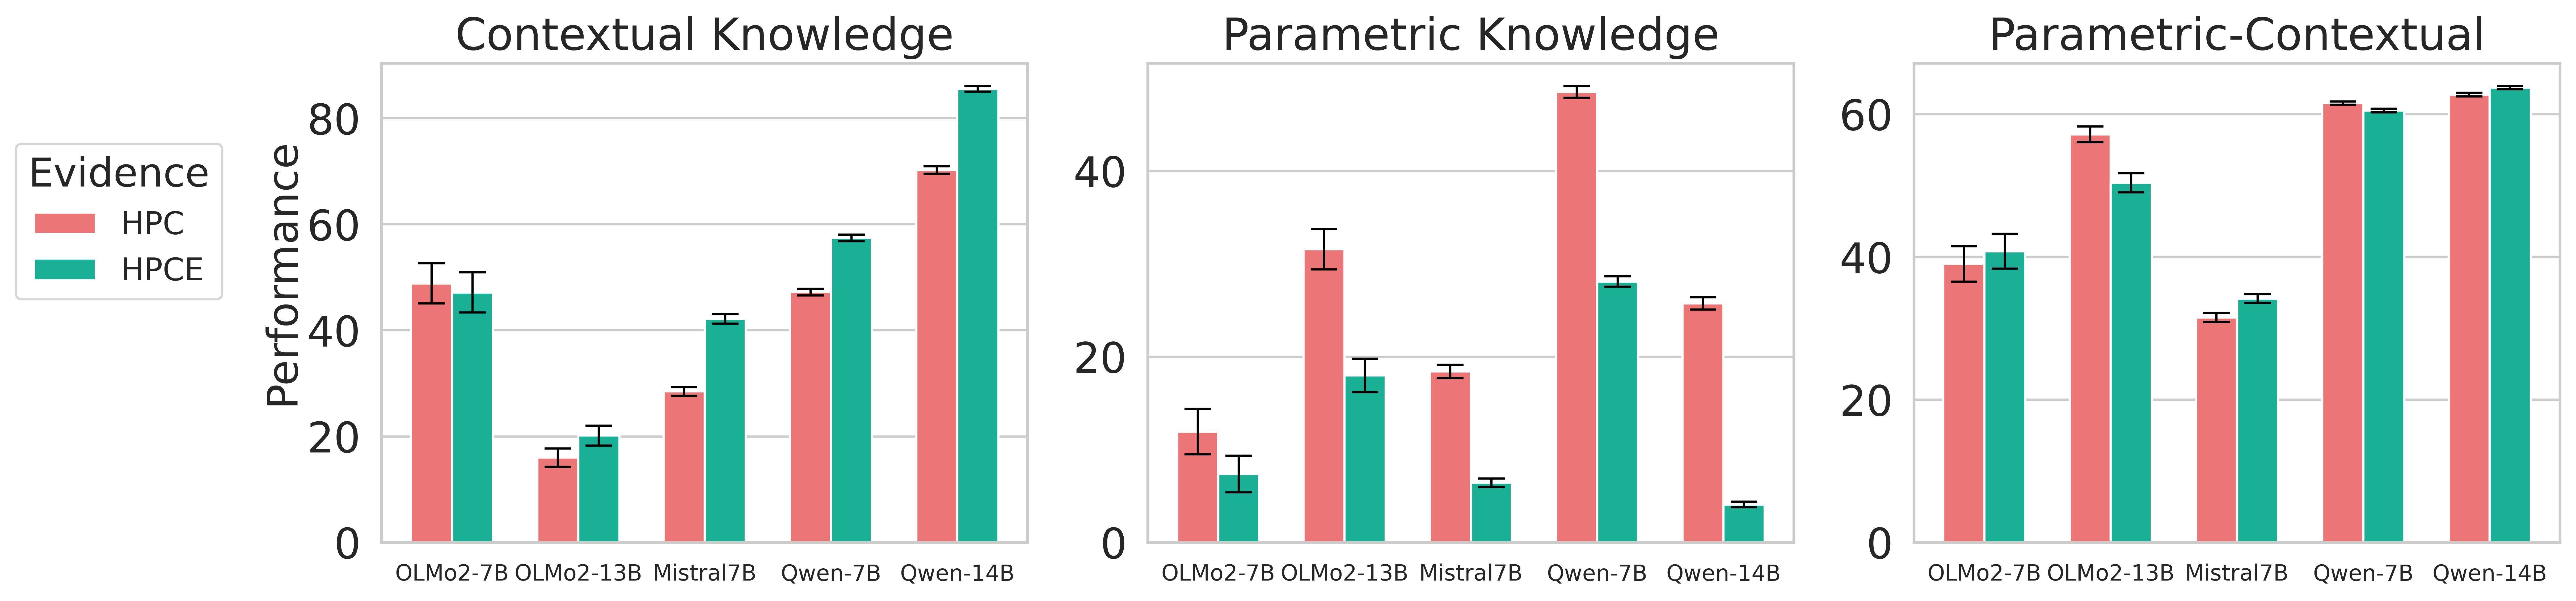

In [7]:
# HPCE Plot

# ------------------------------------------------------------------
# 3)  Create ONE figure with five side‑by‑side sub‑plots  ──────────
# ------------------------------------------------------------------
tasks   = ["CK", "PK", "PCK"]
pretty_tasks   = {"CK": 'Contextual Knowledge', "PK": 'Parametric Knowledge', "PCK": 'Parametric-Contextual'}
n_tasks = len(tasks)

fig, axes = plt.subplots(
    1, n_tasks,
    figsize=(5.0 * n_tasks, 4.5),       # width ∝ number of tasks
    sharey=False                         # <- different y‑axis since metrics differ
)

for ax, t in zip(axes, tasks):
    # Select metric based on task
    if t in ['CK', 'PK']:
        metric_to_plot = "exact_match"
        ylabel = "Accuracy"
    else:  # PCK
        metric_to_plot = "f1"
        ylabel = "F1"
    
    # ------------------------------------------------------------------
    # 0)  Combine the model‑specific DataFrames  ──(unchanged)──────────
    # ------------------------------------------------------------------
    dfs = []
    for name, df in [('OLMo2-7B', perf_olmo),
                     ('OLMo2-13B', perf_olmo13B),
                     ('Mistral7B', perf_mistral),
                     ('Qwen-7B', perf_qwen),
                     ('Qwen-14B', perf_qwen14B)]:
        d = df[df['metric'] == metric_to_plot].copy()
        d['model'] = name
        dfs.append(d)

    data = pd.concat(dfs, ignore_index=True)

    # ------------------------------------------------------------------
    # 1)  Long format   ──(unchanged, but add HPCE if it exists)────────
    # ------------------------------------------------------------------
    evidence_cols = [col for col in ['HPC', 'HPCE'] if col in data.columns]

    long_mean = data.melt(
        id_vars=['model', 'task'],
        value_vars=evidence_cols,
        var_name='evidence',
        value_name=metric_to_plot
    )

    long_sem = data.melt(
        id_vars=['model', 'task'],
        value_vars=[f'{c}_sem' for c in evidence_cols],
        var_name='evidence',
        value_name='sem'
    )
    long_sem['evidence'] = long_sem['evidence'].str.replace('_sem', '', regex=False)

    long = long_mean.merge(long_sem, on=['model', 'task', 'evidence'])  

    # ------------------------------------------------------------------
    # 2)  Colour map that is *fixed* across tasks  ─────────────────────
    # ------------------------------------------------------------------
    # Custom color palette
    PALETTE   = {'NC': '#fdb731', 'HPC': '#ff6363', 'LPC': '#6cd9f9', 'HPCE': '#00c9a7'}
    HUE_ORDER    = evidence_cols                    # keep legend order stable
    
    # choose evidence types for this task
    ev_types = ['HPC', 'HPCE']
    sub = long[(long['task'] == t) & (long['evidence'].isin(ev_types))]
    
    # Rotate xtick label 90 degrees
    sns.barplot(
        ax=ax,
        data=sub,
        x='model', y=metric_to_plot,
        hue='evidence', hue_order=HUE_ORDER,
        palette=PALETTE,
        width=0.65,
        errorbar=None
    )

    for bar, se in zip(ax.patches, sub['sem']):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.errorbar(
            x, y, yerr=se,
            color='black',
            capsize=6, elinewidth=1, capthick=1   # thicker & longer
        )
    
    # cosmetic tweaks per subplot
    ax.set_title(pretty_tasks[t], fontsize=20, pad=6)     # ← label "which part is KF / CK / …"
    ax.set_xlabel('')                       # no per‑panel x‑label
    ax.set_ylabel('') 
    ax.tick_params(axis='x', rotation=0, labelsize=10)  # Rotate x‑tick labels for better readability
fig.text(0.02, 0.5, 'Performance', va='center',
       rotation='vertical', fontsize=19)

# ------------------------------------------------------------------
# 4)  Single shared legend & layout  ───────────────────────────────
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels, title='Evidence',
    loc='upper right', bbox_to_anchor=(0.01, 0.7),
    frameon=True,
    prop={'size': 14}
)
leg.get_title().set_fontsize(18)
for ax in axes:
    ax.get_legend().remove()               # remove per‑axes legends

fig.tight_layout(rect=[0.02, 0, 1, 0.92])     # leave room for the legend title and y-label

# ------------------------------------------------------------------
# 5)  Save & show  ─────────────────────────────────────────────────
# ------------------------------------------------------------------
out_path = os.path.join(os.environ['base_dir'], "results", "figures", f"HPCE_all_metrics.pdf")
fig.savefig(out_path, bbox_inches='tight')
plt.show()

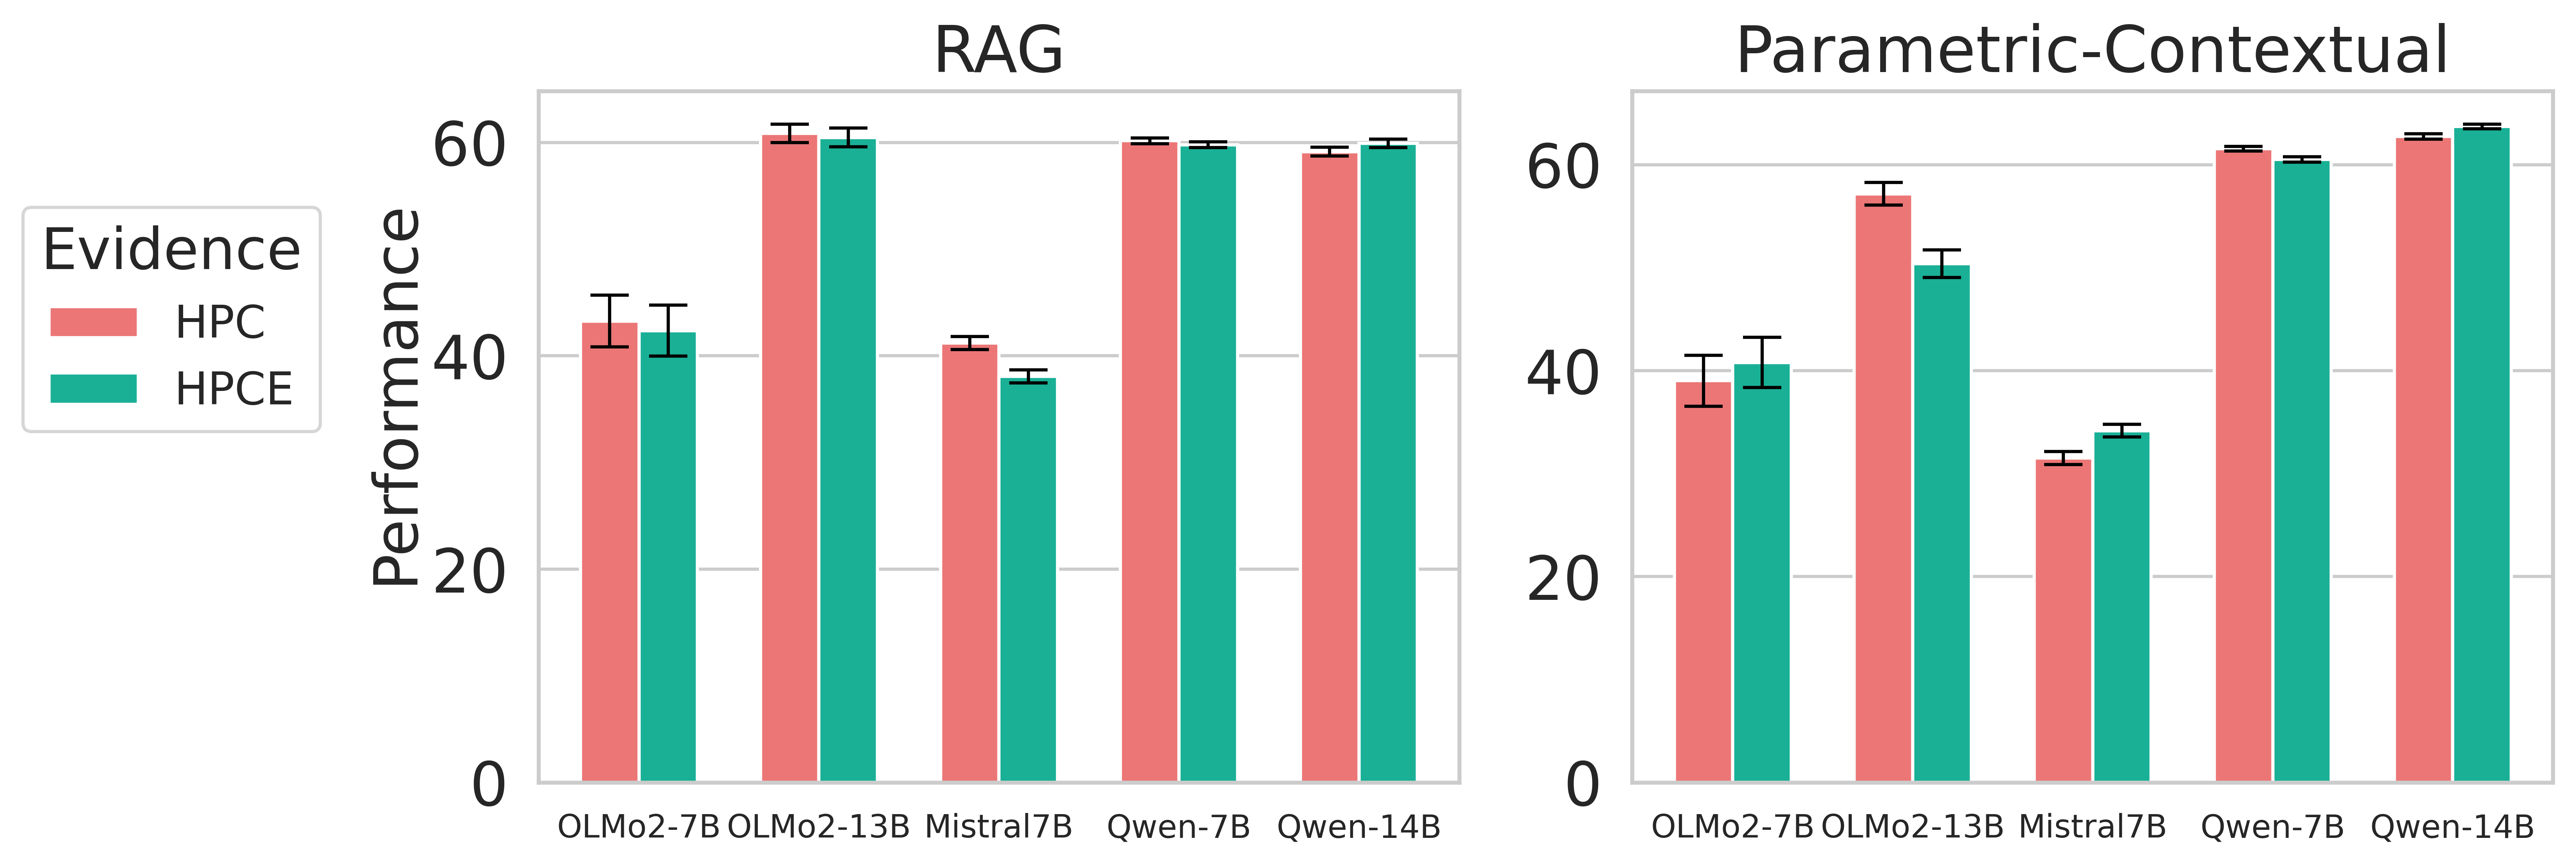

In [30]:
# HPCE Plot

# ------------------------------------------------------------------
# 3)  Create ONE figure with five side‑by‑side sub‑plots  ──────────
# ------------------------------------------------------------------
tasks   = ["RAG", "PCK"]
pretty_tasks   = {"RAG": 'RAG', "PCK": 'Parametric-Contextual'}
n_tasks = len(tasks)

fig, axes = plt.subplots(
    1, n_tasks,
    figsize=(5.0 * n_tasks, 4.5),       # width ∝ number of tasks
    sharey=False                         # <- different y‑axis since metrics differ
)

for ax, t in zip(axes, tasks):
    # Select metric based on task
    if t in ['CK', 'PK']:
        metric_to_plot = "exact_match"
        ylabel = "Accuracy"
    else:  # PCK
        metric_to_plot = "f1"
        ylabel = "F1"
    
    # ------------------------------------------------------------------
    # 0)  Combine the model‑specific DataFrames  ──(unchanged)──────────
    # ------------------------------------------------------------------
    dfs = []
    for name, df in [('OLMo2-7B', perf_olmo),
                     ('OLMo2-13B', perf_olmo13B),
                     ('Mistral7B', perf_mistral),
                     ('Qwen-7B', perf_qwen),
                     ('Qwen-14B', perf_qwen14B)]:
        d = df[df['metric'] == metric_to_plot].copy()
        d['model'] = name
        dfs.append(d)

    data = pd.concat(dfs, ignore_index=True)

    # ------------------------------------------------------------------
    # 1)  Long format   ──(unchanged, but add HPCE if it exists)────────
    # ------------------------------------------------------------------
    evidence_cols = [col for col in ['HPC', 'HPCE'] if col in data.columns]

    long_mean = data.melt(
        id_vars=['model', 'task'],
        value_vars=evidence_cols,
        var_name='evidence',
        value_name=metric_to_plot
    )

    long_sem = data.melt(
        id_vars=['model', 'task'],
        value_vars=[f'{c}_sem' for c in evidence_cols],
        var_name='evidence',
        value_name='sem'
    )
    long_sem['evidence'] = long_sem['evidence'].str.replace('_sem', '', regex=False)

    long = long_mean.merge(long_sem, on=['model', 'task', 'evidence'])  

    # ------------------------------------------------------------------
    # 2)  Colour map that is *fixed* across tasks  ─────────────────────
    # ------------------------------------------------------------------
    PALETTE   = {'NC': '#fdb731', 'HPC': '#ff6363', 'LPC': '#6cd9f9', 'HPCE': '#00c9a7'}
    HUE_ORDER    = evidence_cols                    # keep legend order stable
    
    # choose evidence types for this task
    ev_types = ['HPC', 'HPCE']
    sub = long[(long['task'] == t) & (long['evidence'].isin(ev_types))]
    
    # Rotate xtick label 90 degrees
    sns.barplot(
        ax=ax,
        data=sub,
        x='model', y=metric_to_plot,
        hue='evidence', hue_order=HUE_ORDER,
        palette=PALETTE,
        width=0.65,
        errorbar=None
    )

    for bar, se in zip(ax.patches, sub['sem']):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.errorbar(
            x, y, yerr=se,
            color='black',
            capsize=6, elinewidth=1, capthick=1   # thicker & longer
        )
    
    # cosmetic tweaks per subplot
    ax.set_title(pretty_tasks[t], fontsize=20, pad=6)     # ← label "which part is KF / CK / …"
    ax.set_xlabel('')                       # no per‑panel x‑label
    ax.set_ylabel('') 
    ax.tick_params(axis='x', rotation=0, labelsize=10)  # Rotate x‑tick labels for better readability
fig.text(0.02, 0.5, 'Performance', va='center',
       rotation='vertical', fontsize=19)

# ------------------------------------------------------------------
# 4)  Single shared legend & layout  ───────────────────────────────
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels, title='Evidence',
    loc='upper right', bbox_to_anchor=(0.01, 0.7),
    frameon=True,
    prop={'size': 14}
)
leg.get_title().set_fontsize(18)
for ax in axes:
    ax.get_legend().remove()               # remove per‑axes legends

fig.tight_layout(rect=[0.02, 0, 1, 0.92])     # leave room for the legend title and y-label

# ------------------------------------------------------------------
# 5)  Save & show  ─────────────────────────────────────────────────
# ------------------------------------------------------------------
out_path = os.path.join(os.environ['base_dir'], "results", "figures", f"HPCE_all_metrics.pdf")
fig.savefig(out_path, bbox_inches='tight')
plt.show()

In [11]:
# Create a table for the RAG scenario
# Rows: each model, Columns: HPC performance, LPC performance, HPC-LPC performance

# Filter for RAG task and f1 metric
metric_to_plot = "f1"

# Combine model data
dfs = []
for name, df in [('OLMo2-7B', perf_olmo),
                 ('OLMo2-13B', perf_olmo13B),
                 ('MistralMoE-7B', perf_mistral),
                 ('Qwen2.5-7B', perf_qwen),
                 ('Qwen2.5-14B', perf_qwen14B)]:
    d = df[(df['metric'] == metric_to_plot) & (df['task'] == 'RAG')].copy()
    d['model'] = name
    dfs.append(d)

rag_data = pd.concat(dfs, ignore_index=True)

# Create the table with HPC, LPC, and HPC-LPC columns
rag_table = rag_data[['model', 'HPC', 'LPC', 'HPC_sem', 'LPC_sem']].copy()
rag_table['HPC-LPC'] = rag_table['HPC'] - rag_table['LPC']

# Format values with SEM as "mean ± sem"
rag_table['HPC Performance'] = rag_table.apply(
    lambda row: f"{row['HPC']:.3f} ± {row['HPC_sem']:.3f}", axis=1
)
rag_table['LPC Performance'] = rag_table.apply(
    lambda row: f"{row['LPC']:.3f} ± {row['LPC_sem']:.3f}", axis=1
)
rag_table['HPC - LPC'] = rag_table['HPC-LPC'].apply(lambda x: f"{x:.3f}")

# Select and rename columns for final table
rag_table_final = rag_table[['model', 'HPC Performance', 'LPC Performance', 'HPC - LPC']].copy()
rag_table_final = rag_table_final.rename(columns={'model': 'Model'})
rag_table_final = rag_table_final.set_index('Model')

# Save to CSV
rag_table_final.to_csv(os.path.join(os.environ['base_dir'], "results", "RAG.csv"))